# Single-Snapshot 2D Hopper Forces

This notebook analyzes one LAMMPS particle dump and one matching local contact-force dump.

1. Direct reading of the two files
2. File-format and force-column validation
3. Construction of the 2D normal-force graph

## Conventions

- The simulation plane is **x–y**
- The vertical coordinate is **y**
- The `force` field in the LAMMPS dump is treated as the **normal contact-force magnitude**



## 1. Imports

In [16]:
from pathlib import Path
from typing import Dict, List, Tuple
import pickle

import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import LogNorm, Normalize
from mpl_toolkits.axes_grid1 import make_axes_locatable

import networkx as nx
import numpy as np
import pandas as pd

import os




## 2. File paths

Place this notebook in the same directory as the two output files, or change `DATA_DIR`.

In [17]:

# ---- Force graph parameters ----
FORCE_EPSILON = 1e-12


try:
    from config import PARTICLE_FILE, CONTACT_FILE, OUTPUT_PNG

    print("Running in batch mode")

except ModuleNotFoundError:

    print("Running in interactive mode")

    DATA_DIR = Path(".")

    PARTICLE_FILE = DATA_DIR / (
        "hopper_mur0.0_mus0.0_wallmur0.0_wallmus0.0_last.dump"
    )

    CONTACT_FILE = DATA_DIR / (
        "hopper_mur0.0_mus0.0_wallmur0.0_wallmus0.0_last.forces"
    )

    OUTPUT_PNG = DATA_DIR / "contact_graph.png"

print(f"Particle file: {PARTICLE_FILE}")
print(f"Contact file : {CONTACT_FILE}")
print(f"Output image : {OUTPUT_PNG}")

Running in interactive mode
Particle file: hopper_mur0.0_mus0.0_wallmur0.0_wallmus0.0_last.dump
Contact file : hopper_mur0.0_mus0.0_wallmur0.0_wallmus0.0_last.forces
Output image : contact_graph.png


## 3. File readers

In [18]:
PARTICLE_REQUIRED = {
    "id", "type", "radius", "mass", "x", "y", "z", "c_acontact"
}

CONTACT_COLUMNS = [
    "index",
    "i", "j",
    "F_normal",
    "Fn_x", "Fn_y", "Fn_z",
    "Ft_x", "Ft_y",
    "F_tangential",
    "T_rolling",
]


def read_particle_dump(
    path: str | Path,
) -> Tuple[int, pd.DataFrame]:
    path = Path(path)

    with path.open("r") as handle:
        lines = handle.readlines()

    try:
        timestep_index = next(
            idx for idx, line in enumerate(lines)
            if line.startswith("ITEM: TIMESTEP")
        )
        atoms_index = next(
            idx for idx, line in enumerate(lines)
            if line.startswith("ITEM: ATOMS")
        )
    except StopIteration as exc:
        raise ValueError(
            f"Could not locate LAMMPS particle headers in {path}"
        ) from exc

    timestep = int(lines[timestep_index + 1].strip())
    header_columns = lines[atoms_index].split()[2:]

    missing = PARTICLE_REQUIRED - set(header_columns)
    if missing:
        raise ValueError(
            f"Particle dump is missing columns: {sorted(missing)}"
        )

    df = pd.read_csv(
        path,
        sep=r"\s+",
        skiprows=atoms_index + 1,
        names=header_columns,
        engine="python",
    )

    df["id"] = pd.to_numeric(df["id"], errors="raise").astype(int)
    df["type"] = pd.to_numeric(df["type"], errors="raise").astype(int)

    numeric_columns = [
        column for column in header_columns
        if column not in {"id", "type"}
    ]
    df[numeric_columns] = df[numeric_columns].apply(
        pd.to_numeric,
        errors="coerce",
    )

    df = df.dropna(
        subset=["id", "x", "y", "radius"]
    ).reset_index(drop=True)

    # Compatibility fields used by some later functions.
    for column in ["vx", "vy", "vz", "omegax", "omegay", "omegaz"]:
        if column not in df.columns:
            df[column] = 0.0

    return timestep, df


def read_contact_dump(
    path: str | Path,
) -> Tuple[int, pd.DataFrame]:
    path = Path(path)

    with path.open("r") as handle:
        lines = handle.readlines()

    try:
        timestep_index = next(
            idx for idx, line in enumerate(lines)
            if line.startswith("ITEM: TIMESTEP")
        )
        entries_index = next(
            idx for idx, line in enumerate(lines)
            if line.startswith("ITEM: ENTRIES")
        )
    except StopIteration as exc:
        raise ValueError(
            f"Could not locate LAMMPS local-dump headers in {path}"
        ) from exc

    timestep = int(lines[timestep_index + 1].strip())
    raw_header = lines[entries_index].split()[2:]

    if len(raw_header) != len(CONTACT_COLUMNS):
        raise ValueError(
            "Unexpected contact column count.\n"
            f"Expected {len(CONTACT_COLUMNS)}, "
            f"found {len(raw_header)}.\n"
            f"Header: {raw_header}"
        )

    df = pd.read_csv(
        path,
        sep=r"\s+",
        skiprows=entries_index + 1,
        names=CONTACT_COLUMNS,
        engine="python",
    )

    if df.empty:
        return timestep, df

    df["i"] = pd.to_numeric(df["i"], errors="coerce")
    df["j"] = pd.to_numeric(df["j"], errors="coerce")

    numeric_columns = [
        column for column in CONTACT_COLUMNS
        if column not in {"i", "j"}
    ]
    df[numeric_columns] = df[numeric_columns].apply(
        pd.to_numeric,
        errors="coerce",
    )

    df = df.dropna(subset=["i", "j", "F_normal"])
    df["i"] = df["i"].astype(int)
    df["j"] = df["j"].astype(int)

    # Missing in this dump.
    df["Ft_z"] = 0.0
    df["T_twisting"] = 0.0

    return timestep, df.reset_index(drop=True)

## 4. Read and inspect the two files

In [19]:
particle_step, particles = read_particle_dump(PARTICLE_FILE)
contact_step, contacts = read_contact_dump(CONTACT_FILE)

if particle_step != contact_step:
    raise ValueError(
        f"Timestep mismatch: particles={particle_step}, contacts={contact_step}"
    )

STEP = particle_step

print("Timestep:", STEP)
print("Particles:", len(particles))
print("Contact rows:", len(contacts))
print("Particle columns:", list(particles.columns))
print("Contact columns:", list(contacts.columns))

display(particles.head())
display(contacts.head())

Timestep: 600000
Particles: 1995
Contact rows: 3932
Particle columns: ['id', 'type', 'radius', 'mass', 'x', 'y', 'z', 'c_acontact', 'vx', 'vy', 'vz', 'omegax', 'omegay', 'omegaz']
Contact columns: ['index', 'i', 'j', 'F_normal', 'Fn_x', 'Fn_y', 'Fn_z', 'Ft_x', 'Ft_y', 'F_tangential', 'T_rolling', 'Ft_z', 'T_twisting']


,id,type,radius,mass,x,y,z,c_acontact,vx,vy,vz,omegax,omegay,omegaz
0,380,1,3.14767,13.06340,13.93970,4.61641,0,2,0.0,0.0,0.0,0.0,0.0,0.0
1,249,1,2.31476,5.19523,-18.69870,8.10867,0,2,0.0,0.0,0.0,0.0,0.0,0.0
2,25,1,2.74421,8.65644,4.36492,10.29970,0,3,0.0,0.0,0.0,0.0,0.0,0.0
3,230,1,2.97916,11.07560,9.23938,7.97654,0,3,0.0,0.0,0.0,0.0,0.0,0.0
4,22,1,2.89557,10.16930,14.84930,10.31400,0,4,0.0,0.0,0.0,0.0,0.0,0.0


,index,i,j,F_normal,Fn_x,Fn_y,Fn_z,Ft_x,Ft_y,F_tangential,T_rolling,Ft_z,T_twisting
0,1,380,230,51.008051,41.495501,-29.663861,0,-4.430959,-6.198278,7.619189,1.189320e-12,0.0,0.0
1,2,380,22,35.137487,-5.539094,-34.698148,0,8.656373,-1.381874,8.765978,2.390340e-12,0.0,0.0
2,3,249,321,31.263000,13.645377,-28.127902,0,-6.845339,-3.320804,7.608312,3.093925e-12,0.0,0.0
3,4,249,271,69.209759,-49.385340,-48.487926,0,-2.984726,3.039967,4.260280,-6.689715e-14,0.0,0.0
4,5,25,230,44.002456,-39.721768,18.931383,0,-0.043735,-0.091764,0.101653,4.530409e-13,0.0,0.0


In [20]:
# are all particles the same type?
print(particles["type"].value_counts())

type
1    1995
Name: count, dtype: int64


## 5. Validate the force columns
`F_normal` should agree with the magnitude of `(Fn_x, Fn_y, Fn_z)`.  
`F_tangential` should agree with the magnitude of `(Ft_x, Ft_y, Ft_z)`.

In [21]:
contacts_validation = contacts.copy()

contacts_validation["Fn_vector_magnitude"] = np.sqrt(
    contacts_validation["Fn_x"]**2
    + contacts_validation["Fn_y"]**2
    + contacts_validation["Fn_z"]**2
)

contacts_validation["Ft_vector_magnitude"] = np.sqrt(
    contacts_validation["Ft_x"]**2
    + contacts_validation["Ft_y"]**2
    + contacts_validation["Ft_z"]**2
)

contacts_validation["Fn_difference"] = np.abs(
    contacts_validation["F_normal"]
    - contacts_validation["Fn_vector_magnitude"]
)

contacts_validation["Ft_difference"] = np.abs(
    contacts_validation["F_tangential"]
    - contacts_validation["Ft_vector_magnitude"]
)

print("Mean normal-force difference:", contacts_validation["Fn_difference"].mean())
print("Maximum normal-force difference:", contacts_validation["Fn_difference"].max())
print("Mean tangential-force difference:", contacts_validation["Ft_difference"].mean())
print("Maximum tangential-force difference:", contacts_validation["Ft_difference"].max())

Mean normal-force difference: 1.775413263654003e-15
Maximum normal-force difference: 2.1316282072803006e-14
Mean tangential-force difference: 1.382749873792348e-16
Maximum tangential-force difference: 7.105427357601002e-15


## 6. Clean contacts and build the force graph with weight=force

In [22]:
def edge_key(u: int, v: int) -> Tuple[int, int]:
    return (u, v) if u <= v else (v, u)


def clean_contacts(
    contacts: pd.DataFrame,
    valid_particle_ids: set[int],
    force_epsilon: float = 1.0e-12,
) -> pd.DataFrame:
    df = contacts.copy()

    df = df.dropna(subset=["i", "j", "F_normal"])
    df = df[df["i"] != df["j"]]

    df = df[
        df["i"].isin(valid_particle_ids)
        & df["j"].isin(valid_particle_ids)
    ]

    df = df[np.isfinite(df["F_normal"])]
    df = df[df["F_normal"] > force_epsilon]

    df["u"] = df[["i", "j"]].min(axis=1).astype(int)
    df["v"] = df[["i", "j"]].max(axis=1).astype(int)

    df = (
        df.sort_values("F_normal", ascending=False)
        .drop_duplicates(["u", "v"], keep="first")
        .reset_index(drop=True)
    )

    return df


def build_force_graph(
    particles: pd.DataFrame,
    contacts: pd.DataFrame,
    force_epsilon: float = 1.0e-12,
) -> Tuple[nx.Graph, Dict[int, np.ndarray], pd.DataFrame]:
    positions = {
        int(row.id): np.array([row.x, row.y], dtype=float)
        for row in particles.itertuples(index=False)
    }

    valid_ids = set(positions)
    clean = clean_contacts(
        contacts,
        valid_ids,
        force_epsilon,
    )

    G = nx.Graph()

    for row in particles.itertuples(index=False):
        G.add_node(
            int(row.id),
            x=float(row.x),
            y=float(row.y),
            radius=float(row.radius),
            mass=float(row.mass),
            contact_count=int(row.c_acontact),
        )

    for row in clean.itertuples(index=False):
        force = float(row.F_normal)

        G.add_edge(
            int(row.u),
            int(row.v),
            force=force,
            normal_force=force,
            tangential_force=float(row.F_tangential),
            rolling_torque=float(row.T_rolling),
            twisting_torque=float(row.T_twisting),
            fn_x=float(row.Fn_x),
            fn_y=float(row.Fn_y),
            fn_z=float(row.Fn_z),
            ft_x=float(row.Ft_x),
            ft_y=float(row.Ft_y),
            ft_z=float(row.Ft_z),
            #weight=1.0 / force,
            weight=force,
        )

    return G, positions, clean

In [23]:
G, positions, clean_contacts = build_force_graph(
    particles,
    contacts,
    force_epsilon=FORCE_EPSILON,
)
print("Graph nodes:", G.number_of_nodes())
print("Graph edges:", G.number_of_edges())
print("Clean contacts:", len(clean_contacts))
print("Mean degree:", np.mean([degree for _, degree in G.degree()]))

Graph nodes: 1995
Graph edges: 3932
Clean contacts: 3932
Mean degree: 3.941854636591479


## 7. Visualize particles

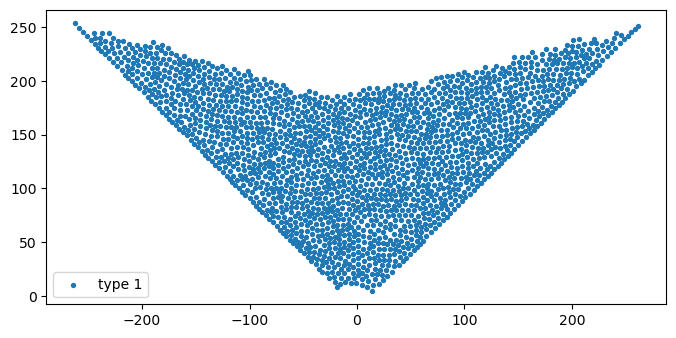

In [24]:
fig, ax = plt.subplots(figsize=(8,8))

for t, subset in particles.groupby("type"):
    ax.scatter(
        subset.x,
        subset.y,
        s=8,
        label=f"type {t}",
    )

ax.legend()
ax.set_aspect("equal")
plt.show()

## 8. Build graph

In [25]:


def build_force_weight_graph(
    source_graph: nx.Graph,
    threshold_mode: str = "mean",
    threshold_value: float | None = 1.0,
) -> nx.Graph:
    
    #Construct a force-weighted contact graph and optionally filter edges.
    #GF = the candidate force-chain network. 
    #It contains only contacts strong enough to satisfy chosen criterion (mean, percentile, fixed threshold, etc.).

    valid_modes = {"mean", "fixed", "percentile", "none"}

    threshold_mode = threshold_mode.lower()

    if threshold_mode not in valid_modes:
        raise ValueError(
            f"threshold_mode must be one of {sorted(valid_modes)}."
        )

    if threshold_mode != "none" and threshold_value is None:
        raise ValueError(
            f"threshold_value is required for mode '{threshold_mode}'."
        )

    # Collect valid positive forces.
    all_forces = np.asarray(
        [
            float(data["force"])
            for _, _, data in source_graph.edges(data=True)
            if "force" in data
            and np.isfinite(float(data["force"]))
            and float(data["force"]) > 0
        ],
        dtype=float,
    )

    if all_forces.size == 0:
        raise ValueError(
            "Source graph contains no valid positive forces."
        )

    mean_force = float(np.mean(all_forces))

    # Determine the force threshold. Add description.
    if threshold_mode == "mean":
        ratio_threshold = float(threshold_value)
        actual_force_threshold = ratio_threshold * mean_force

        threshold_description = (
            f"F / <F> >= {ratio_threshold:.4g} "
            f"(F >= {actual_force_threshold:.4g})"
        )

    elif threshold_mode == "fixed":
        actual_force_threshold = float(threshold_value)

        threshold_description = (
            f"F >= {actual_force_threshold:.4g}"
        )

    elif threshold_mode == "percentile":
        percentile = float(threshold_value)

        if not 0 <= percentile <= 100:
            raise ValueError(
                "For percentile mode, threshold_value must be "
                "between 0 and 100."
            )

        actual_force_threshold = float(
            np.percentile(all_forces, percentile)
        )

        threshold_description = (
            f"F >= {actual_force_threshold:.4g} "
            f"({percentile:.1f}th percentile)"
        )

    else:
        actual_force_threshold = -np.inf
        threshold_description = "all positive-force contacts"

    GF = nx.Graph()
    GF.add_nodes_from(source_graph.nodes(data=True))

    retained_edges = 0

    for u, v, data in source_graph.edges(data=True):
        force = float(data.get("force", np.nan))

        if not np.isfinite(force) or force <= 0:
            continue

        if force < actual_force_threshold:
            continue

        edge_data = data.copy()

        # Raw force used as graph weight.
        edge_data["weight"] = force

        # Store normalized force as an additional attribute.
        edge_data["normalized_force"] = force / mean_force

        GF.add_edge(u, v, **edge_data)
        retained_edges += 1

    isolated_nodes = list(nx.isolates(GF))
    GF.remove_nodes_from(isolated_nodes)

    if GF.number_of_edges() == 0:
        raise ValueError(
            "No edges remain after applying the force threshold."
        )

    total_edges = source_graph.number_of_edges()

    print(f"Threshold mode: {threshold_mode}")
    print(f"Threshold: {threshold_description}")
    print(f"Mean source force: {mean_force:.6g}")
    print(
        f"Retained edges: {retained_edges:,} / {total_edges:,} "
        f"({100 * retained_edges / total_edges:.1f}%)"
    )
    print(f"Removed isolated nodes: {len(isolated_nodes):,}")

    # Save useful information in the graph itself.
    GF.graph["threshold_mode"] = threshold_mode
    GF.graph["threshold_value"] = threshold_value
    GF.graph["threshold_description"] = threshold_description
    GF.graph["mean_force"] = mean_force

    return GF

In [26]:
def plot_force_weight_graph(
    particles,
    positions,
    GF, #filtered graph
    title=None,
    color_by="force",
    log_color=True,
    save_path="contact_graph.png",
):
    #Plot a force-filtered graph.

    #Parameters
    #----------
    #color_by
    #    "force" plots raw force.
    #    "normalized_force" plots F / <F>.

    #log_color?
    #    If True, use logarithmic color normalization.
    #    If False, use linear color normalization.
    

    valid_color_options = {"force", "normalized_force"}

    if color_by not in valid_color_options:
        raise ValueError(
            f"color_by must be one of {sorted(valid_color_options)}."
        )

    fig, ax = plt.subplots(figsize=(11, 9)) #create matplotlib figure

    #particles
    ax.scatter(
        particles["x"],
        particles["y"],
        s=5,
        color="lightgray",
        alpha=0.15,
        zorder=1,
    )

    segments = []
    values = []
    raw_forces = []

    #loop over every edge
    for u, v, data in GF.edges(data=True):
        if u not in positions or v not in positions:
            continue

        # Use only x and y coordinates for 2D -- in case positions are 3D.
        p1 = np.asarray(positions[u])[:2]
        p2 = np.asarray(positions[v])[:2]

        segments.append([p1, p2]) #store line segment
        values.append(float(data[color_by])) #store color mode
        raw_forces.append(float(data["force"])) #store force

    if not segments:
        raise ValueError(
            "No drawable edges were found in the graph."
        )

    values = np.asarray(values, dtype=float)
    raw_forces = np.asarray(raw_forces, dtype=float)

    if log_color:
        positive_values = values[values > 0]

        if positive_values.size == 0:
            raise ValueError(
                "Log color scaling requires positive values."
            )

        norm = LogNorm(
            vmin=positive_values.min(),
            vmax=positive_values.max(),
        )
    else:
        norm = Normalize(
            vmin=values.min(),
            vmax=values.max(),
        )


    force_scaled = raw_forces / raw_forces.max() 
    linewidths = 0.6 + 3.0 * force_scaled #computes line width

    #create line collection
    lc = LineCollection(
        segments,
        array=values,
        cmap="magma_r",
        norm=norm,
        linewidths=linewidths,
        alpha=0.9,
        zorder=2,
    )
    
    #draw edges
    ax.add_collection(lc) 

    divider = make_axes_locatable(ax)
    cax = divider.append_axes(
        "right",
        size="4%",
        pad=0.08,
    )

    cbar = fig.colorbar(lc, cax=cax)

    if color_by == "normalized_force":
        cbar.set_label(r"Normalized force, $F/\langle F\rangle$")
    else:
        cbar.set_label("Force")

    threshold_description = GF.graph.get(
        "threshold_description",
        "filtered contacts",
    )

    if title is None:
        title = f"Contact graph: {threshold_description}"

    ax.set_aspect("equal")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(title)

    plt.tight_layout()


    if save_path is not None:
        fig.savefig(
            save_path,
            #dpi=300,
            #Note: lower dpi for movies
            #dpi=150
            bbox_inches="tight",
            facecolor="white",
        )

    plt.show()
    plt.close(fig)


## Plot

## Selecting the Force Filtering Method

Choose the filtering method with `threshold_mode` and specify its cutoff using `threshold_value`.

| Mode | Description |
|------|-------------|
| `"mean"` | Normalize force by the mean force. |
| `"fixed"` | Use an absolute force threshold. |
| `"percentile"` | Keep the strongest contacts above a percentile. |
| `"none"` | Keep all contacts with positive force. |

**Criteria**

- **`threshold_mode="mean"`**

  $$
  \frac{F}{\langle F\rangle} \geq \text{threshold\_value}
  $$

  Example: `threshold_value=1.0` keeps contacts with force at least equal to the mean.

- **`threshold_mode="fixed"`**

  $$
  F \geq \text{threshold\_value}
  $$

  Example: `threshold_value=20.0` keeps contacts with $$F \geq 20$$.

- **`threshold_mode="percentile"`**

  `threshold_value=70` keeps the strongest 30% of contacts.

- **`threshold_mode="none"`**

  Keeps all contacts with positive force.

Example:

```python
GF = build_force_weight_graph(
    G,
    threshold_mode="mean",      # "mean", "fixed", "percentile", or "none"
    threshold_value=1.0,        # Not used for "none"
)
```

Threshold mode: none
Threshold: all positive-force contacts
Mean source force: 11.8703
Retained edges: 3,932 / 3,932 (100.0%)
Removed isolated nodes: 0


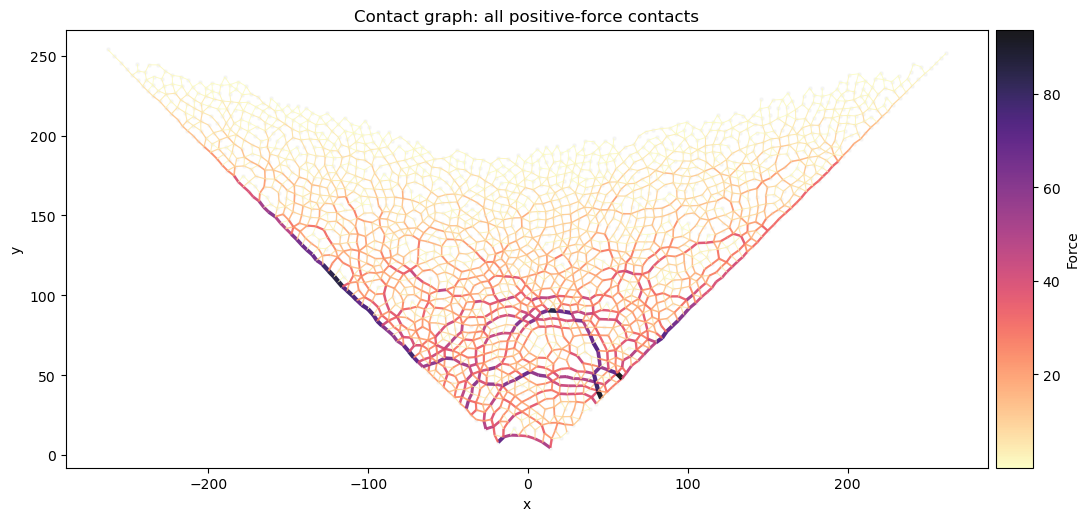

In [27]:
#Plot all: no filter
GF = build_force_weight_graph(
    G,
    threshold_mode="none",
    threshold_value=0,
)

plot_force_weight_graph(
    particles,
    positions,
    GF,
    color_by="force",
    log_color=False,
    save_path=OUTPUT_PNG, #remove this line if you don't want the figure saved to disk
)


Threshold mode: mean
Threshold: F / <F> >= 1 (F >= 11.87)
Mean source force: 11.8703
Retained edges: 1,361 / 3,932 (34.6%)
Removed isolated nodes: 973


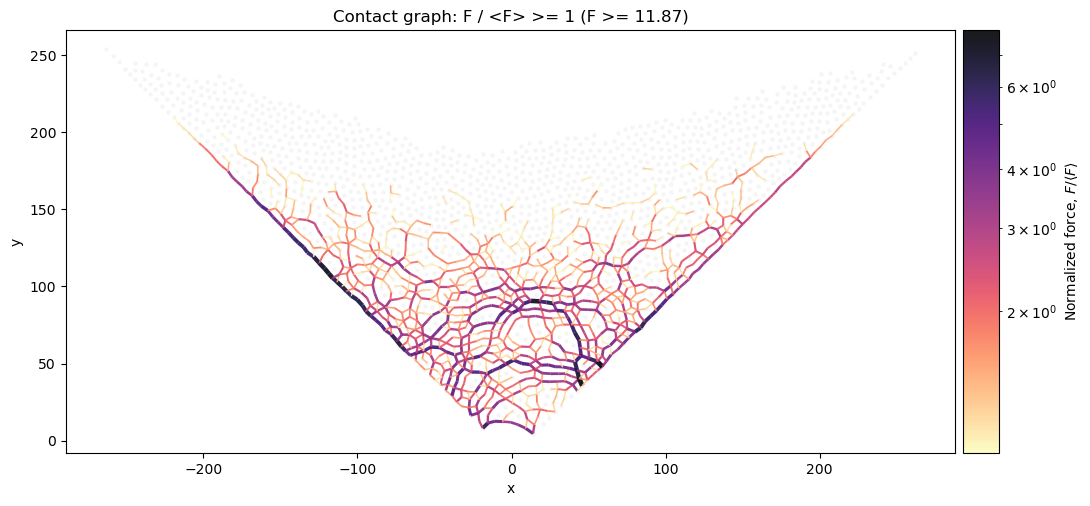

In [28]:
#Plot F above mean
GF = build_force_weight_graph(
    G,
    threshold_mode="mean",
    threshold_value=1.0, #keep all above mean
)

plot_force_weight_graph(
    particles,
    positions,
    GF,
    color_by="normalized_force",
    log_color=True,
    #save_path=OUTPUT_PNG,

)


Threshold mode: fixed
Threshold: F >= 20
Mean source force: 11.8703
Retained edges: 764 / 3,932 (19.4%)
Removed isolated nodes: 1,310


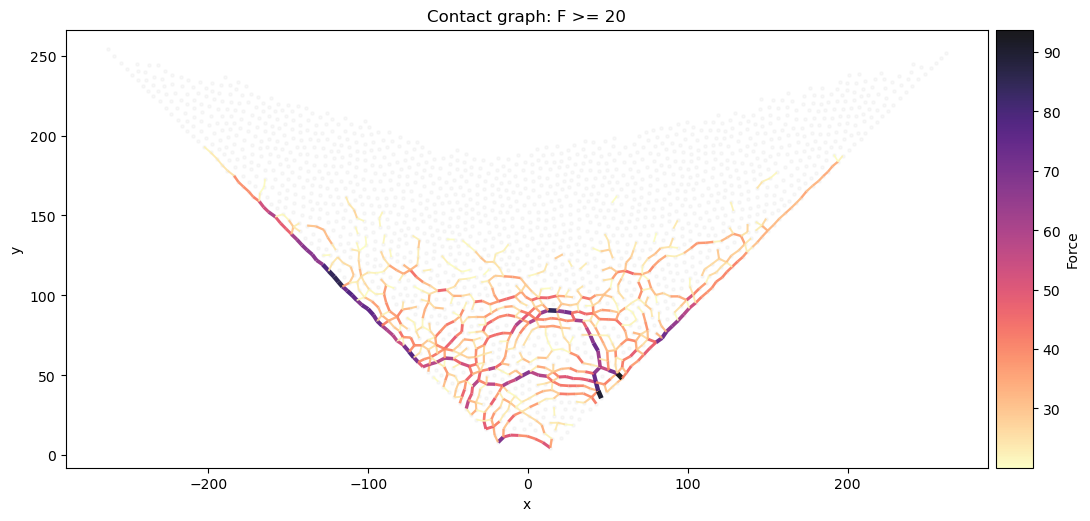

In [29]:
#Plot above a threshold
GF = build_force_weight_graph(
    G,
    threshold_mode="fixed",
    threshold_value=20,
)

plot_force_weight_graph(
    particles,
    positions,
    GF,
    color_by="force",
    log_color=False,
    #save_path=OUTPUT_PNG,
)


Threshold mode: percentile
Threshold: F >= 29.51 (90.0th percentile)
Mean source force: 11.8703
Retained edges: 394 / 3,932 (10.0%)
Removed isolated nodes: 1,577


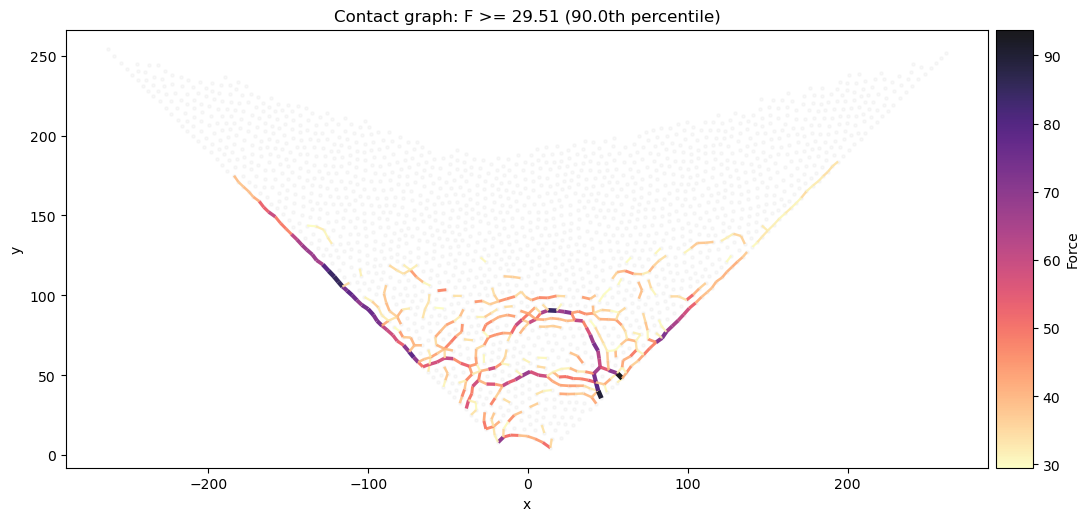

In [30]:
#Plot a percentile
GF = build_force_weight_graph(
    G,
    threshold_mode="percentile",
    threshold_value=90,
)

plot_force_weight_graph(
    particles,
    positions,
    GF,
    color_by="force",
    log_color=False,
    #save_path=OUTPUT_PNG,
)
